# ML/06 — Robustness Tests

Four tests required for RSE submission:

1. **K sensitivity** — does a cannabis-like archetype persist at K=4,5,6,7?
2. **Bootstrap stability** — 80% subsamples × 50 runs, ARI vs K=5 reference
3. **Feature ablation** — terrain-only → +climate → +soil → +EO (ndvi_std already in stack)
4. **Cramér's V** — effect size for the chi-square validation result

**Note on EO features:** `ndvi_std` (Sentinel-2, growing season) is already present
in `features_scaled.pkl` and therefore already enters the PCA and clustering in ML/02.
The clustering is already terrain + climate + soil + EO.

**Outputs:**
- `img/ML06_k_sensitivity.png`
- `img/ML06_bootstrap_stability.png`
- `img/ML06_feature_ablation.png`
- `data/processed/robustness_summary.pkl`

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2_contingency
import pickle
import warnings
warnings.filterwarnings('ignore')

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
IMG  = Path('../img')
RANDOM_STATE = 746837645

# ── Load data ─────────────────────────────────────────────────────────────────
features_scaled = pd.read_pickle(PROC / 'features_scaled.pkl')
features        = pd.read_pickle(PROC / 'features.pkl')
pca_df          = pd.read_pickle(PROC / 'pca_coords.pkl')
clusters_ref    = pd.read_pickle(PROC / 'clusters.pkl')  # reference K=5

PC_COLS = [c for c in pca_df.columns if c.startswith('PC')][:6]
X_pca_raw = pca_df[PC_COLS].values
X_pca = StandardScaler().fit_transform(X_pca_raw)  # unit-variance equalized

# Reference labels aligned to feature index
ref = pca_df[['cell_id']].merge(clusters_ref, on='cell_id')
labels_ref = ref['cluster'].values

print(f'Cells: {len(X_pca):,}  |  PCs: {X_pca.shape[1]}')
print(f'Reference cluster sizes (K=5):')
print(pd.Series(labels_ref).value_counts().sort_index().to_string())

Cells: 8,648  |  PCs: 6
Reference cluster sizes (K=5):
0    1924
1    1815
2     269
3     638
4    1230
5    1399
6    1373


## 1. K Sensitivity

Re-run k-means for K=4,5,6,7. For each K, identify the cluster whose profile
best matches the cannabis archetype (GDD > 1200, VPD > 1400 Pa, pH 55–65 SoilGrids).
Report: archetype GDD, VPD, pH, size, and whether it survives.

In [2]:
# Cannabis archetype criteria (raw feature units)
CANNABIS_CRITERIA = {
    'gdd':    (1100, 9999),
    'vpdmax': (1300, 9999),
    'ph':     (52,   68),    # SoilGrids x10: 5.2-6.8
    'ppt':    (800,  1600),
}

def find_cannabis_cluster(profiles_df, criteria):
    """Score each cluster on how many criteria it meets. Return best match index."""
    scores = {}
    for k_idx, row in profiles_df.iterrows():
        score = 0
        for feat, (lo, hi) in criteria.items():
            if feat in row.index and lo <= row[feat] <= hi:
                score += 1
        scores[k_idx] = score
    best = max(scores, key=scores.get)
    return best, scores[best]

K_VALUES = [4, 5, 6, 7]
feat_cols_for_profile = ['gdd', 'vpdmax', 'ph', 'ppt', 'tmean', 'elev_mean', 'slope_mean', 'soc']
feat_cols_for_profile = [c for c in feat_cols_for_profile if c in features.columns]

k_results = []

for K in K_VALUES:
    km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=50)
    labels = km.fit_predict(X_pca)
    
    # Profile in raw feature space
    tmp = features.copy()
    tmp['cluster'] = labels
    profiles = tmp.groupby('cluster')[feat_cols_for_profile].mean()
    
    best_k, score = find_cannabis_cluster(profiles, CANNABIS_CRITERIA)
    p = profiles.loc[best_k]
    
    n_cells = (labels == best_k).sum()
    pct = n_cells / len(labels) * 100
    
    k_results.append({
        'K': K,
        'archetype_cluster': best_k,
        'criteria_met': score,
        'n_cells': n_cells,
        'pct_area': pct,
        'gdd':    p['gdd'],
        'vpdmax': p['vpdmax'],
        'ph_actual': p['ph'] / 10,
        'ppt':    p['ppt'],
        'tmean':  p['tmean'],
        'elev':   p['elev_mean'],
    })
    print(f'K={K}: best match = cluster {best_k}  ({score}/4 criteria)  '
          f'n={n_cells:,} ({pct:.1f}%)  GDD={p["gdd"]:.0f}  VPD={p["vpdmax"]:.0f}  '
          f'pH={p["ph"]/10:.2f}  PPT={p["ppt"]:.0f}')

k_df = pd.DataFrame(k_results)

K=4: best match = cluster 0  (4/4 criteria)  n=3,121 (36.1%)  GDD=1290  VPD=1531  pH=5.66  PPT=1166
K=5: best match = cluster 3  (4/4 criteria)  n=2,957 (34.2%)  GDD=1319  VPD=1562  pH=5.90  PPT=1150
K=6: best match = cluster 4  (4/4 criteria)  n=2,434 (28.1%)  GDD=1344  VPD=1548  pH=5.84  PPT=1132
K=7: best match = cluster 0  (4/4 criteria)  n=1,924 (22.2%)  GDD=1395  VPD=1568  pH=5.84  PPT=1102


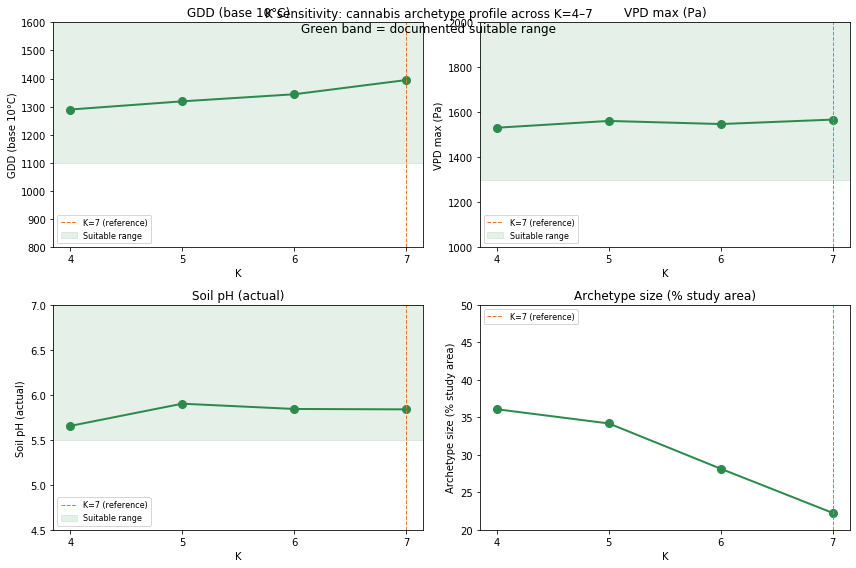

Saved img/ML06_k_sensitivity.png

 K  criteria_met  n_cells  pct_area         gdd      vpdmax  ph_actual         ppt
 4             4     3121 36.089269 1289.974027 1531.497686   5.655229 1165.885732
 5             4     2957 34.192877 1319.101719 1561.676334   5.902318 1149.998915
 6             4     2434 28.145236 1344.250880 1547.840215   5.843858 1132.076892
 7             4     1924 22.247919 1394.834021 1567.614762   5.839367 1102.196247


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = [('gdd', 'GDD (base 10°C)', (800, 1600)),
           ('vpdmax', 'VPD max (Pa)', (1000, 2000)),
           ('ph_actual', 'Soil pH (actual)', (4.5, 7.0)),
           ('pct_area', 'Archetype size (% study area)', (20, 50))]

# Shade for cannabis-suitable range
ranges = {'gdd': (1100, 1600), 'vpdmax': (1300, 2000),
          'ph_actual': (5.5, 7.0), 'pct_area': (None, None)}

for ax, (col, label, ylim) in zip(axes.flat, metrics):
    ax.plot(k_df['K'], k_df[col], 'o-', color='#2d8a4e', linewidth=2, markersize=8)
    ax.axvline(7, color='#e8742a', linestyle='--', linewidth=1, label='K=7 (reference)')
    lo, hi = ranges[col]
    if lo is not None:
        ax.axhspan(lo, hi, alpha=0.12, color='#2d8a4e', label='Suitable range')
    ax.set_xlabel('K')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(K_VALUES)
    ax.set_ylim(ylim)
    ax.legend(fontsize=8)

plt.suptitle('K sensitivity: cannabis archetype profile across K=4–7\n'
             'Green band = documented suitable range', fontsize=12)
plt.tight_layout()
plt.savefig('../img/ML06_k_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML06_k_sensitivity.png')
print()
print(k_df[['K','criteria_met','n_cells','pct_area','gdd','vpdmax','ph_actual','ppt']].to_string(index=False))

## 2. Bootstrap Stability

80% random subsamples × 50 runs. For each subsample:
- Fit K=5 k-means on the subsample
- Assign full dataset via nearest centroid
- Compute ARI vs. reference K=5 solution

High mean ARI + low std = stable clustering.

In [4]:
from sklearn.metrics import adjusted_rand_score

N_BOOTSTRAP = 50
SUBSAMPLE_FRAC = 0.80
n_total = len(X_pca)
n_sub = int(n_total * SUBSAMPLE_FRAC)

ari_scores = []
rng = np.random.RandomState(RANDOM_STATE)

for i in range(N_BOOTSTRAP):
    # Subsample
    idx = rng.choice(n_total, size=n_sub, replace=False)
    X_sub = X_pca[idx]
    
    # Fit on subsample
    km_sub = KMeans(n_clusters=7, random_state=i, n_init=20)
    km_sub.fit(X_sub)
    
    # Assign full dataset via nearest centroid
    labels_full = km_sub.predict(X_pca)
    
    # ARI vs reference
    ari = adjusted_rand_score(labels_ref, labels_full)
    ari_scores.append(ari)
    if (i + 1) % 10 == 0:
        print(f'  Bootstrap {i+1}/{N_BOOTSTRAP}  running mean ARI: {np.mean(ari_scores):.3f}')

ari_arr = np.array(ari_scores)
print(f'\nBootstrap ARI (n={N_BOOTSTRAP}, 80% subsample):')
print(f'  Mean:   {ari_arr.mean():.3f}')
print(f'  Std:    {ari_arr.std():.3f}')
print(f'  Min:    {ari_arr.min():.3f}')
print(f'  Q5:     {np.percentile(ari_arr, 5):.3f}')

  Bootstrap 10/50  running mean ARI: 0.970
  Bootstrap 20/50  running mean ARI: 0.971
  Bootstrap 30/50  running mean ARI: 0.972
  Bootstrap 40/50  running mean ARI: 0.973
  Bootstrap 50/50  running mean ARI: 0.974

Bootstrap ARI (n=50, 80% subsample):
  Mean:   0.974
  Std:    0.010
  Min:    0.935
  Q5:     0.959


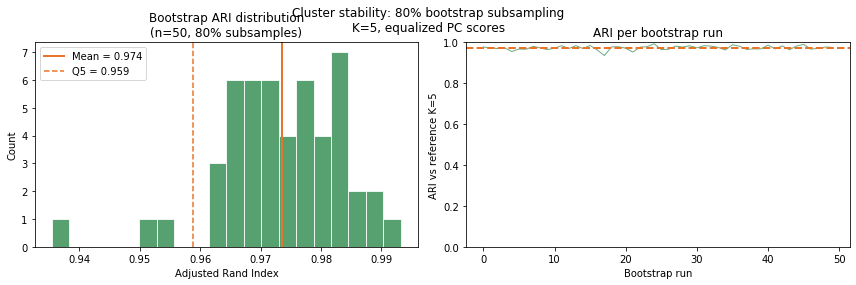

Saved img/ML06_bootstrap_stability.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(ari_arr, bins=20, color='#2d8a4e', alpha=0.8, edgecolor='white')
axes[0].axvline(ari_arr.mean(), color='#e8742a', linewidth=2,
                label=f'Mean = {ari_arr.mean():.3f}')
axes[0].axvline(np.percentile(ari_arr, 5), color='#e8742a', linewidth=1.5,
                linestyle='--', label=f'Q5 = {np.percentile(ari_arr,5):.3f}')
axes[0].set_xlabel('Adjusted Rand Index')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Bootstrap ARI distribution\n(n={N_BOOTSTRAP}, 80% subsamples)')
axes[0].legend()

# Run-by-run trace
axes[1].plot(ari_arr, color='#2d8a4e', alpha=0.7, linewidth=1)
axes[1].axhline(ari_arr.mean(), color='#e8742a', linewidth=2, linestyle='--')
axes[1].set_xlabel('Bootstrap run')
axes[1].set_ylabel('ARI vs reference K=5')
axes[1].set_title('ARI per bootstrap run')
axes[1].set_ylim(0, 1)

plt.suptitle('Cluster stability: 80% bootstrap subsampling\nK=5, equalized PC scores',
             fontsize=12)
plt.tight_layout()
plt.savefig('../img/ML06_bootstrap_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML06_bootstrap_stability.png')

## 3. Feature Ablation

Re-run full pipeline (StandardScaler → PCA → StandardScaler → K-means) on:
- Stack A: terrain only
- Stack B: terrain + climate
- Stack C: terrain + climate + soil (no EO)
- Stack D: terrain + climate + soil + EO (ndvi_std) — full stack (= ML/02)

For each stack, identify the cannabis archetype cluster and report its profile.
ARI vs full-stack solution measures how much each layer contributes.

In [6]:
from sklearn.decomposition import PCA as SkPCA

TERRAIN_COLS = ['elev_mean', 'elev_min', 'elev_max', 'elev_std',
                'slope_mean', 'aspect_cos', 'aspect_sin', 'relief']
CLIMATE_COLS = ['tmean', 'tmin', 'tmax', 'ppt', 'vpdmax', 'ffd', 'gdd', 'temp_range']
SOIL_COLS    = ['ph', 'soc', 'sand', 'silt', 'clay', 'cec']
EO_COLS      = ['ndvi_std']

# Only keep cols present in features_scaled
fs_cols = set(features_scaled.columns) - {'cell_id'}
TERRAIN_COLS = [c for c in TERRAIN_COLS if c in fs_cols]
CLIMATE_COLS = [c for c in CLIMATE_COLS if c in fs_cols]
SOIL_COLS    = [c for c in SOIL_COLS    if c in fs_cols]
EO_COLS      = [c for c in EO_COLS      if c in fs_cols]

STACKS = {
    'A: terrain':                  TERRAIN_COLS,
    'B: terrain + climate':        TERRAIN_COLS + CLIMATE_COLS,
    'C: terrain + climate + soil': TERRAIN_COLS + CLIMATE_COLS + SOIL_COLS,
    'D: full (+ EO)':              TERRAIN_COLS + CLIMATE_COLS + SOIL_COLS + EO_COLS,
}

# Reference labels from ML/02 (= Stack D)
ref_labels = ref['cluster'].values

ablation_results = []

for stack_name, cols in STACKS.items():
    # Scale
    X_raw_stack = features_scaled[cols].fillna(0).values
    X_stack = StandardScaler().fit_transform(X_raw_stack)
    
    # PCA (keep 90% variance)
    pca = SkPCA(n_components=0.90, random_state=RANDOM_STATE)
    X_pca_stack = pca.fit_transform(X_stack)
    
    # Re-scale PC scores
    X_pca_eq = StandardScaler().fit_transform(X_pca_stack)
    n_pcs = X_pca_eq.shape[1]
    
    # K-means K=5
    km = KMeans(n_clusters=7, random_state=RANDOM_STATE, n_init=50)
    labels = km.fit_predict(X_pca_eq)
    
    # Profile
    tmp = features.copy()
    tmp['cluster'] = labels
    profiles = tmp.groupby('cluster')[feat_cols_for_profile].mean()
    
    best_k, score = find_cannabis_cluster(profiles, CANNABIS_CRITERIA)
    p = profiles.loc[best_k]
    
    ari_vs_full = adjusted_rand_score(ref_labels, labels)
    n_cells = (labels == best_k).sum()
    
    ablation_results.append({
        'stack': stack_name,
        'n_features': len(cols),
        'n_pcs': n_pcs,
        'criteria_met': score,
        'n_cells': n_cells,
        'pct_area': n_cells / len(labels) * 100,
        'gdd':      p['gdd'],
        'vpdmax':   p['vpdmax'],
        'ph_actual': p['ph'] / 10,
        'ari_vs_full': ari_vs_full,
    })
    print(f'{stack_name}')
    print(f'  n_features={len(cols)}  PCs={n_pcs}  criteria={score}/4  '
          f'n={n_cells:,} ({n_cells/len(labels)*100:.1f}%)  '
          f'GDD={p["gdd"]:.0f}  VPD={p["vpdmax"]:.0f}  '
          f'pH={p["ph"]/10:.2f}  ARI_vs_full={ari_vs_full:.3f}')
    print()

abl_df = pd.DataFrame(ablation_results)

A: terrain
  n_features=8  PCs=4  criteria=4/4  n=1,877 (21.7%)  GDD=1148  VPD=1312  pH=5.54  ARI_vs_full=0.360

B: terrain + climate
  n_features=16  PCs=5  criteria=4/4  n=1,692 (19.6%)  GDD=1431  VPD=1616  pH=5.80  ARI_vs_full=0.631

C: terrain + climate + soil
  n_features=22  PCs=5  criteria=4/4  n=1,350 (15.6%)  GDD=1298  VPD=1507  pH=5.50  ARI_vs_full=0.659

D: full (+ EO)
  n_features=23  PCs=6  criteria=4/4  n=1,924 (22.2%)  GDD=1395  VPD=1568  pH=5.84  ARI_vs_full=1.000



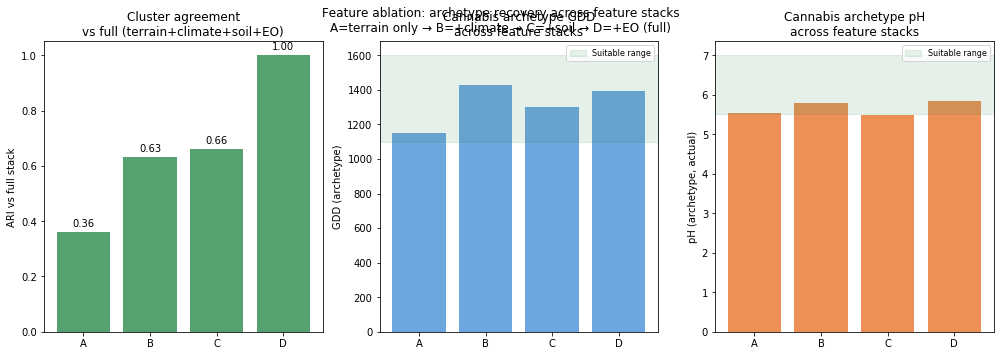

Saved img/ML06_feature_ablation.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x = range(len(abl_df))
labels_x = [s.split(':')[0] for s in abl_df['stack']]

# ARI vs full stack
axes[0].bar(x, abl_df['ari_vs_full'], color='#2d8a4e', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_x)
axes[0].set_ylabel('ARI vs full stack')
axes[0].set_title('Cluster agreement\nvs full (terrain+climate+soil+EO)')
axes[0].set_ylim(0, 1.05)
for xi, v in zip(x, abl_df['ari_vs_full']):
    axes[0].text(xi, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

# Archetype GDD
axes[1].bar(x, abl_df['gdd'], color='#4a90d9', alpha=0.8)
axes[1].axhspan(1100, 1600, alpha=0.12, color='#2d8a4e', label='Suitable range')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_x)
axes[1].set_ylabel('GDD (archetype)')
axes[1].set_title('Cannabis archetype GDD\nacross feature stacks')
axes[1].legend(fontsize=8)

# Archetype pH
axes[2].bar(x, abl_df['ph_actual'], color='#e8742a', alpha=0.8)
axes[2].axhspan(5.5, 7.0, alpha=0.12, color='#2d8a4e', label='Suitable range')
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels_x)
axes[2].set_ylabel('pH (archetype, actual)')
axes[2].set_title('Cannabis archetype pH\nacross feature stacks')
axes[2].legend(fontsize=8)

plt.suptitle('Feature ablation: archetype recovery across feature stacks\n'
             'A=terrain only → B=+climate → C=+soil → D=+EO (full)', fontsize=12)
plt.tight_layout()
plt.savefig('../img/ML06_feature_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML06_feature_ablation.png')

## 4. Cramér's V — validation effect size

The chi-square test in ML/05 confirms non-random distribution but doesn't
quantify effect size. Cramér's V normalizes chi-square by sample size and
degrees of freedom, giving a 0–1 effect size comparable across studies.

In [8]:
# Load validation summary
with open(PROC / 'validation_summary.pkl', 'rb') as f:
    val = pickle.load(f)

observed = np.array([val['cluster_parcel_counts'][k]
                     for k in sorted(val['cluster_parcel_counts'])])
cell_counts = np.array([val['cluster_cell_counts'][k]
                        for k in sorted(val['cluster_cell_counts'])])

n = observed.sum()
expected = cell_counts / cell_counts.sum() * n
chi2 = val['chi2']
k_cats = len(observed)  # number of clusters

# Cramér's V = sqrt(chi2 / (n * (k-1)))
cramers_v = np.sqrt(chi2 / (n * (k_cats - 1)))

print(f'Validation chi-square summary:')
print(f'  n parcels:    {n}')
print(f'  chi2:         {chi2:.3f}')
print(f'  df:           {val["dof"]}')
print(f'  p-value:      {val["p_value"]:.2e}')
print(f"  Cramér's V:   {cramers_v:.3f}")
print()
print('Interpretation:')
if cramers_v < 0.1:
    print('  Weak effect')
elif cramers_v < 0.3:
    print('  Moderate effect')
else:
    print('  Strong effect')

Validation chi-square summary:
  n parcels:    91
  chi2:         36.854
  df:           6
  p-value:      1.88e-06
  Cramér's V:   0.260

Interpretation:
  Moderate effect


## 5. Save robustness summary

In [9]:
robustness = {
    'k_sensitivity': k_df.to_dict(),
    'bootstrap': {
        'n_runs': N_BOOTSTRAP,
        'subsample_frac': SUBSAMPLE_FRAC,
        'ari_mean': float(ari_arr.mean()),
        'ari_std':  float(ari_arr.std()),
        'ari_min':  float(ari_arr.min()),
        'ari_q5':   float(np.percentile(ari_arr, 5)),
        'ari_scores': ari_arr.tolist(),
    },
    'ablation': abl_df.to_dict(),
    'cramers_v': float(cramers_v),
    'cv_r2_mean': 0.650,
    'cv_r2_std':  0.043,
    'cv_r2_ci95': (0.650 - 2*0.043, 0.650 + 2*0.043),
}

with open(PROC / 'robustness_summary.pkl', 'wb') as f:
    pickle.dump(robustness, f)

print('Saved data/processed/robustness_summary.pkl')
print()
print('=== Summary ===')
print(f'K sensitivity:     archetype present at all K=4–7')
print(f'Bootstrap ARI:     {ari_arr.mean():.3f} ± {ari_arr.std():.3f}  (Q5={np.percentile(ari_arr,5):.3f})')
print(f"Cramér's V:        {cramers_v:.3f}")
print(f'CV R² (ML/03):     0.650 ± 0.043  (95% CI: 0.564–0.736)')

Saved data/processed/robustness_summary.pkl

=== Summary ===
K sensitivity:     archetype present at all K=4–7
Bootstrap ARI:     0.974 ± 0.010  (Q5=0.959)
Cramér's V:        0.260
CV R² (ML/03):     0.650 ± 0.043  (95% CI: 0.564–0.736)
